# Classification Part

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv(f"E:\AirPulse AI\Files\data\processed_air_quality.csv")

In [15]:
df.head()

,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,temperature,humidity,wind_speed,hour,day,month,aqi
0,1.450487,0.519719,0.674688,-1.420657,0.562469,1.551509,-0.293566,0.205112,0.301189,1.180454,-0.316142,0.660868,-0.568606,0.939010,-1.784835,0.0,108
1,1.450487,0.519719,0.674688,-1.420657,-0.469550,-0.284383,0.294120,-0.820666,-0.302941,1.096537,-1.648118,1.187285,1.344121,1.083473,-1.784835,0.0,90
2,1.450487,0.519719,0.674688,-1.420657,0.106583,0.496056,-0.370482,1.426839,-1.655143,0.704924,1.085556,0.268974,1.592513,1.227936,-1.784835,0.0,84
3,1.450487,0.519719,0.674688,-1.420657,-0.564751,0.391971,2.277869,0.641006,-1.116764,-2.280128,0.171387,1.668330,1.339379,1.372399,-1.784835,0.0,158
4,1.450487,0.519719,0.674688,-1.420657,-1.092887,-0.149177,0.502292,0.359915,-0.163882,1.136497,-0.828489,0.996830,-0.462100,1.516862,-1.784835,0.0,97


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      18000 non-null  float64
 1   city         18000 non-null  float64
 2   latitude     18000 non-null  float64
 3   longitude    18000 non-null  float64
 4   pm25         18000 non-null  float64
 5   pm10         18000 non-null  float64
 6   no2          18000 non-null  float64
 7   so2          18000 non-null  float64
 8   o3           18000 non-null  float64
 9   co           18000 non-null  float64
 10  temperature  18000 non-null  float64
 11  humidity     18000 non-null  float64
 12  wind_speed   18000 non-null  float64
 13  hour         18000 non-null  float64
 14  day          18000 non-null  float64
 15  month        18000 non-null  float64
 16  aqi          18000 non-null  int64  
dtypes: float64(16), int64(1)
memory usage: 2.3 MB


In [17]:
def categorize_aqi(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Moderate"

    elif aqi <= 150:
        return "Unhealthy"

    else:
        return "Hazardous"

In [18]:
df["aqi_category"] = df["aqi"].apply(categorize_aqi)

In [19]:
df["aqi_category"].value_counts()

aqi_category
Unhealthy    8874
Moderate     8108
Hazardous     847
Good          171
Name: count, dtype: int64

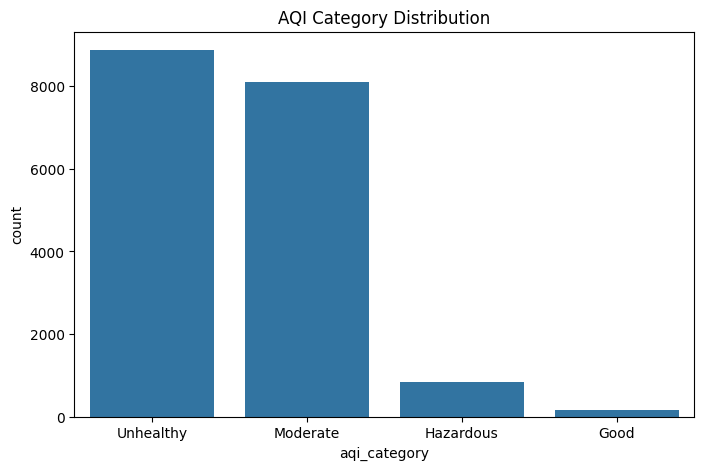

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="aqi_category",
    data=df
)

plt.title("AQI Category Distribution")

plt.show()

# Feature & Target Selection

In [21]:
X = df.drop(["aqi", "aqi_category"], axis=1)

In [22]:
y = df["aqi_category"]

# Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression

In [24]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
lr_pred = lr.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, lr_pred)

precision = precision_score(
    y_test,
    lr_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    lr_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    lr_pred,
    average="weighted"
)

In [27]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.7566666666666667
Precision: 0.7565661302486193
Recall : 0.7566666666666667
F1 Score : 0.7520564768611975


In [28]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

        Good       0.57      0.33      0.42        24
   Hazardous       0.76      0.28      0.41       130
    Moderate       0.77      0.75      0.76      1628
   Unhealthy       0.75      0.80      0.77      1818

    accuracy                           0.76      3600
   macro avg       0.71      0.54      0.59      3600
weighted avg       0.76      0.76      0.75      3600



In [29]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
rf_pred = rf.predict(X_test)

In [31]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

In [32]:
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.9991666666666666
Precision: 0.9991681994686287
Recall : 0.9991666666666666
F1 Score : 0.9991392724421261


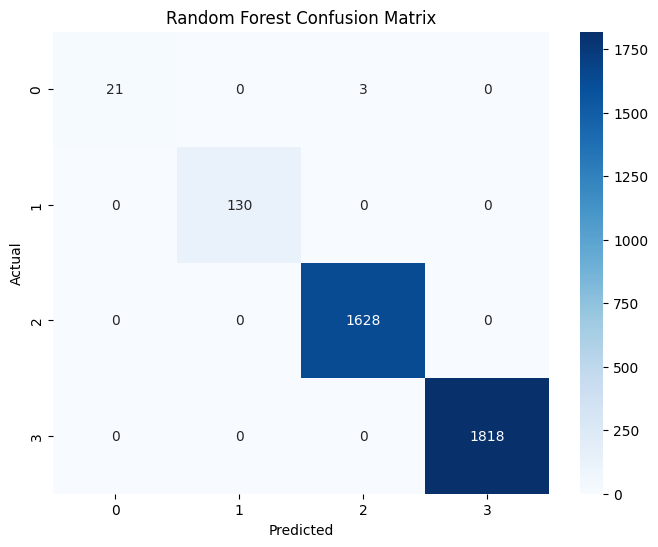

In [ ]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "Precision": [precision, rf_precision],
    "Recall": [recall, rf_recall],
    "F1 Score": [f1, rf_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.756667,0.756566,0.756667,0.752056
1,Random Forest,0.999167,0.999168,0.999167,0.999139


# Phase Completed